# Previsão da quantidade de feridos em Sinistros de Trânsito nas rodovias Brasileiras

## Entendimento do Negócio

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent 
sys.path.append(str(ROOT))

In [2]:
# importando as bibliotecas
import pandas as pd
from data_understanding.unzip_files import *
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", None)
import numpy as np

In [3]:
# Descompactando os arquivos
# saida = unzip_files(os.path.join(ROOT,'contents'))

# saida

In [4]:
# Gerando a base única
bases = generate_files(os.path.join(ROOT,'contents/arquivos_descompactados'))

bases.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,10.0,11/06/2007,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,0,5,0,4,6,NaN,NaN,NaN,NaN,NaN
1,10.0,11/06/2007,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,0,5,0,4,6,NaN,NaN,NaN,NaN,NaN
2,1032898.0,13/08/2007,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,...,1,2,0,1,1,NaN,NaN,NaN,NaN,NaN
3,1051130.0,12/02/2007,Segunda,02:10:00,MA,135,11,SAO LUIS,Animais na Pista,Atropelamento de animal,...,1,0,0,3,1,NaN,NaN,NaN,NaN,NaN
4,1066824.0,20/11/2007,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,...,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN


### Analisando a distribuição dos dados

In [5]:
# Analisando o tamanho de cada tabela
_, _, tam_bases = check_consistencia_colunas(os.path.join(ROOT,'contents/arquivos_descompactados'))

tam_bases

{'datatran2007.csv': 127675,
 'datatran2008.csv': 141043,
 'datatran2009.csv': 158646,
 'datatran2010.csv': 183469,
 'datatran2011.csv': 192326,
 'datatran2012.csv': 184568,
 'datatran2013.csv': 186748,
 'datatran2014.csv': 169201,
 'datatran2015.csv': 122161,
 'datatran2016.csv': 96363,
 'datatran2017.csv': 89567,
 'datatran2018.csv': 69333,
 'datatran2019.csv': 67558,
 'datatran2020.csv': 63585,
 'datatran2021.csv': 64567,
 'datatran2022.csv': 64606,
 'datatran2023.csv': 67766,
 'datatran2024.csv': 73156,
 'datatran2025.csv': 72496}

In [6]:
bases.columns

Index(['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km',
       'municipio', 'causa_acidente', 'tipo_acidente',
       'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
       'ano', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos',
       'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional',
       'delegacia', 'uop'],
      dtype='object')

In [7]:
bases.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2194834 entries, 0 to 72495
Data columns (total 31 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      float64
 1   data_inversa            object 
 2   dia_semana              object 
 3   horario                 object 
 4   uf                      object 
 5   br                      object 
 6   km                      object 
 7   municipio               object 
 8   causa_acidente          object 
 9   tipo_acidente           object 
 10  classificacao_acidente  object 
 11  fase_dia                object 
 12  sentido_via             object 
 13  condicao_metereologica  object 
 14  tipo_pista              object 
 15  tracado_via             object 
 16  uso_solo                object 
 17  ano                     float64
 18  pessoas                 int64  
 19  mortos                  int64  
 20  feridos_leves           int64  
 21  feridos_graves          int64  
 22  i

Como são encontradas 31 colunas, vamos separá-las em categóricas e numéricas para analisá-las.

In [8]:
col_cat = []
col_num = []

for col in bases.columns:
    if bases[col].dtype == 'object':
        col_cat.append(col)
    elif bases[col].dtype == 'float' or  bases[col].dtype == 'int64':
        col_num.append(col)

In [9]:
print(f"Colunas Categóricas - {col_cat}")
print(f"Colunas Numéricas - {col_num}")

print(len(col_cat) + len(col_num))

Colunas Categóricas - ['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']
Colunas Numéricas - ['id', 'ano', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos']
31


Se faz necessário alterar o tipo dos valores de algumas colunas:
* data_inversa -> date
* horário -> datetime
* br -> int64
* km -> float64
* ano -> int64

Checando como os valores estão apresentados

In [10]:
for col in col_cat:
    print(f"{col} - {bases[col].unique()}")

data_inversa - ['11/06/2007' '13/08/2007' '12/02/2007' ... '2025-12-29' '2025-12-30'
 '2025-12-31']
dia_semana - ['Segunda' 'Terça' 'Domingo' 'Quinta' 'Quarta' 'Sexta' 'Sábado' 'domingo'
 'segunda-feira' 'terça-feira' 'quarta-feira' 'quinta-feira' 'sexta-feira'
 'sábado']
horario - ['15:30:00' '14:25:00' '02:10:00' ... '00:20:47' '08:08:30' '01:31:40']
uf - ['MG' 'MA' 'CE' 'PR' 'ES' 'GO' 'RJ' 'RS' 'SP' 'RN' 'SC' 'PA' 'PE' 'MT'
 'BA' 'AL' 'TO' 'PI' 'MS' 'SE' 'RO' 'PB' 'AP' 'DF' 'AC' 'RR' 'AM' '(null)']
br - ['381' '40' '135' '222' '230' '277' '101' '251' '70' '116' '158' '280'
 '470' '60' '386' '376' '316' '10' '232' '262' '282' '473' '242' '290'
 '153' '50' '343' '104' '267' '163' '365' '304' '364' '392' '20' '287'
 '235' '367' '472' '402' '293' '226' '324' '210' '354' '414' '476' '495'
 '424' '373' '471' '110' '393' '319' '601' '463' '452' '406' '407' '285'
 '493' '174' '605' '317' '428' '408' '459' '468' '418' '146' '465' '469'
 '450' '423' '401' '488' '356' '405' '410' '259' '361' '

Informações importantes de padronização:
* todas as colunas apresentam o valor : '(null)' aonde se faz necessário substituir por nulo
* A coluna de br apresenta valores do tipo float com ponto (.) e outos com vírgula (,)
* A coluna de dia da semana apresenta valores com escrita distinta para indicar os mesmos dias
* As colunas de latitude e longitude estão com vírgula ao invés de ponto


Modificando o tipo das colunas

In [11]:
df = bases.copy()

In [12]:
# substituindo os valores escritos (null) por nulos de fato
bases.replace('(null)',np.nan,inplace=True)

# substituindo as vírgulas por pontos
bases['km'] = (
    bases['km']
    .astype(str)
    .str.strip()
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.-]', '', regex=True)
    .replace('', None)
    .pipe(pd.to_numeric, errors='coerce')
)

bases['br'] = (
    bases['br']
    .astype(str)
    .str.strip()
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.-]', '', regex=True)
    .replace('', None)
    .pipe(pd.to_numeric, errors='coerce')
)


bases['longitude'] = (
    bases['longitude']
    .astype(str)
    .str.strip()
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.-]', '', regex=True)
    .replace('', None)
    .pipe(pd.to_numeric, errors='coerce')
)


bases['latitude'] = (
    bases['latitude']
    .astype(str)
    .str.strip()
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.-]', '', regex=True)
    .replace('', None)
    .pipe(pd.to_numeric, errors='coerce')
)

bases['data'] = (
    pd.to_datetime(bases['data_inversa'], format='%Y-%m-%d', errors='coerce')
    .fillna(pd.to_datetime(bases['data_inversa'], format='%d/%m/%Y', errors='coerce'))
    .fillna(pd.to_datetime(bases['data_inversa'], format='%d/%m/%y', errors='coerce'))
)

Padronizando algumas classificações

In [13]:
dias_semana = {
    'segunda-feira':'segunda',
    'terça-feira':'terca',
    'quarta-feira':'quarta',
    'quinta-feira':'quinta',
    'sexta-feira':'sexta',
    'sábado':'sabado',
    'segunda':'segunda',
    'terça':'terca',
    'quarta':'quarta',
    'quinta':'quinta',
    'sexta':'sexta',
    'domingo':'domingo',
    'sabado':'sabado'
}

bases['dia_semana_novo'] = bases['dia_semana'].str.lower().map(dias_semana)

In [14]:
bases['condicao_metereologica'] = bases['condicao_metereologica'].str.lower()

bases['condicao_metereologica'] = bases['condicao_metereologica'].str.replace('céu','ceu')

bases['condicao_metereologica'] = bases['condicao_metereologica'].str.replace('ignorada','ignorado')

bases['fase_dia'] = bases['fase_dia'].str.lower()

In [15]:
for col in col_cat:
    print(f"{col} - {bases[col].unique()}")

data_inversa - ['11/06/2007' '13/08/2007' '12/02/2007' ... '2025-12-29' '2025-12-30'
 '2025-12-31']
dia_semana - ['Segunda' 'Terça' 'Domingo' 'Quinta' 'Quarta' 'Sexta' 'Sábado' 'domingo'
 'segunda-feira' 'terça-feira' 'quarta-feira' 'quinta-feira' 'sexta-feira'
 'sábado']
horario - ['15:30:00' '14:25:00' '02:10:00' ... '00:20:47' '08:08:30' '01:31:40']
uf - ['MG' 'MA' 'CE' 'PR' 'ES' 'GO' 'RJ' 'RS' 'SP' 'RN' 'SC' 'PA' 'PE' 'MT'
 'BA' 'AL' 'TO' 'PI' 'MS' 'SE' 'RO' 'PB' 'AP' 'DF' 'AC' 'RR' 'AM' nan]
br - [381.  40. 135. 222. 230. 277. 101. 251.  70. 116. 158. 280. 470.  60.
 386. 376. 316.  10. 232. 262. 282. 473. 242. 290. 153.  50. 343. 104.
 267. 163. 365. 304. 364. 392.  20. 287. 235. 367. 472. 402. 293. 226.
 324. 210. 354. 414. 476. 495. 424. 373. 471. 110. 393. 319. 601. 463.
 452. 406. 407. 285. 493. 174. 605. 317. 428. 408. 459. 468. 418. 146.
 465. 469. 450. 423. 401. 488. 356. 405. 410. 259. 361. 480. 427. 460.
 156. 330. 425. 377. 432.  80. 308. 419. 412. 429. 485. 433.  nan 6

In [16]:
#bases['data_inversa'] = pd.to_datetime(bases['data_inversa'], format='%d/%m/%Y')
bases['horario'] = pd.to_datetime(bases["horario"]).dt.time

C:\Users\User\AppData\Local\Temp\ipykernel_13068\224235312.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bases['horario'] = pd.to_datetime(bases["horario"]).dt.time


In [17]:
# verificar os valores das colunas numéricas
for col in col_num:
    print(f"{col} - {bases[col].unique()}")

id - [1.000000e+01 1.032898e+06 1.051130e+06 ... 7.481710e+05 7.484890e+05
 7.486810e+05]
ano - [2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015.   nan]
pessoas - [  9   3   5   1   2   4  14   7   6   8  11  18  16  54  13  23  10  31
  45  12  17  15  43  27  47  19  39  26  22  34  21  33  28  40  59  25
  50  38  20  42  53  24  29  46  48  44  32  30  80  35  36  51  41  37
  64  49  57  66  55  73  52  58  99  62  82  63  65  61  60  87 248 103
  92  56  88  91  70  67  75  81  78  74  95  68  93  69  71  76]
mortos - [ 0  2  1  4  3  7  6  5 11  9 14  8 13 15 12 10 33 26 17 21 19 23 37 16]
feridos_leves - [ 4  0  2  1  3  5 11  7  6 12 13  9 10 15  8 18 14 20 21 28 35 38 43 29
 17 26 16 19 30 37 52 22 40 24 44 33 34 25 36 23 41 27 31 32 50 46 39 45
 42 49 47 58 61 83]
feridos_graves - [  0   1   2   3   4   6   8   5  16  17   9  27   7  14  11  30  12  10
  18  13  22  34  19  15  39  21  20  46  31  32  23  42 222  38  29  25
  26  24  28  35]
ilesos - [ 5  2  0  1  4  3 

In [18]:
for col in col_num:
    print(f'{col} - {bases[col].dtype}')

id - float64
ano - float64
pessoas - int64
mortos - int64
feridos_leves - int64
feridos_graves - int64
ilesos - int64
ignorados - int64
feridos - int64
veiculos - int64


Checando valores nulos

In [19]:
for col in bases.columns:
    if bases[col].isnull().sum() > 0:
        print(f"{col} - {bases[col].isnull().sum()}")

uf - 12
br - 12
km - 12
causa_acidente - 2
tipo_acidente - 41
classificacao_acidente - 36
fase_dia - 70
condicao_metereologica - 61
tipo_pista - 10
tracado_via - 10
uso_solo - 10
ano - 728997
latitude - 1562200
longitude - 1562200
regional - 1562229
delegacia - 1562437
uop - 1562634


A quantidade de valores nulos muito grandes pode indicar que em algumas bases talvez elas não fizessem parte. Vamos checar se todas as tabelas apresentam a mesma estrutura de colunas

In [22]:
# verificando se todas as tabelas apresentam a mesma estrutura de colunas
colunas_tabelas, qtd_colunas_tabela, _ = check_consistencia_colunas(os.path.join(ROOT,'contents/arquivos_descompactados'))

qtd_colunas_tabela

{'datatran2007.csv': 26,
 'datatran2008.csv': 26,
 'datatran2009.csv': 26,
 'datatran2010.csv': 26,
 'datatran2011.csv': 26,
 'datatran2012.csv': 26,
 'datatran2013.csv': 26,
 'datatran2014.csv': 26,
 'datatran2015.csv': 26,
 'datatran2016.csv': 25,
 'datatran2017.csv': 30,
 'datatran2018.csv': 30,
 'datatran2019.csv': 30,
 'datatran2020.csv': 30,
 'datatran2021.csv': 30,
 'datatran2022.csv': 30,
 'datatran2023.csv': 30,
 'datatran2024.csv': 30,
 'datatran2025.csv': 30}

Percebe-se que:
* Entre o conteúdo de 2007 até 2015 os dados tinham 26 colunas [coluna ano]
* Apenas em 2016 os dados passaram para 25 colunas [remoção da coluna ano]
* Entre 2017 até 2025 os dados contém 30 colunas [adição das colunas latitude, longitude, regional, delegacia e uop]

Logo, vão existir colunas que apresentarão uma quantidade muito grande de dados nulos pois elas existem apenas em intervalos de dados. 

Agora se faz necessário entender se essas colunas faltantes são importantes para seguirem no dataset ou se serão deletadas.

In [23]:
colunas_tabelas['datatran2015.csv'] # presença da coluna -> ano

['id',
 'data_inversa',
 'dia_semana',
 'horario',
 'uf',
 'br',
 'km',
 'municipio',
 'causa_acidente',
 'tipo_acidente',
 'classificacao_acidente',
 'fase_dia',
 'sentido_via',
 'condicao_metereologica',
 'tipo_pista',
 'tracado_via',
 'uso_solo',
 'ano',
 'pessoas',
 'mortos',
 'feridos_leves',
 'feridos_graves',
 'ilesos',
 'ignorados',
 'feridos',
 'veiculos']

In [24]:
colunas_tabelas['datatran2016.csv'] # remoção da coluna ano

['id',
 'data_inversa',
 'dia_semana',
 'horario',
 'uf',
 'br',
 'km',
 'municipio',
 'causa_acidente',
 'tipo_acidente',
 'classificacao_acidente',
 'fase_dia',
 'sentido_via',
 'condicao_metereologica',
 'tipo_pista',
 'tracado_via',
 'uso_solo',
 'pessoas',
 'mortos',
 'feridos_leves',
 'feridos_graves',
 'ilesos',
 'ignorados',
 'feridos',
 'veiculos']

In [25]:
colunas_tabelas['datatran2025.csv'] # adição das colunas latitude, longitude, regional, delegacia e uop

['id',
 'data_inversa',
 'dia_semana',
 'horario',
 'uf',
 'br',
 'km',
 'municipio',
 'causa_acidente',
 'tipo_acidente',
 'classificacao_acidente',
 'fase_dia',
 'sentido_via',
 'condicao_metereologica',
 'tipo_pista',
 'tracado_via',
 'uso_solo',
 'pessoas',
 'mortos',
 'feridos_leves',
 'feridos_graves',
 'ilesos',
 'ignorados',
 'feridos',
 'veiculos',
 'latitude',
 'longitude',
 'regional',
 'delegacia',
 'uop']

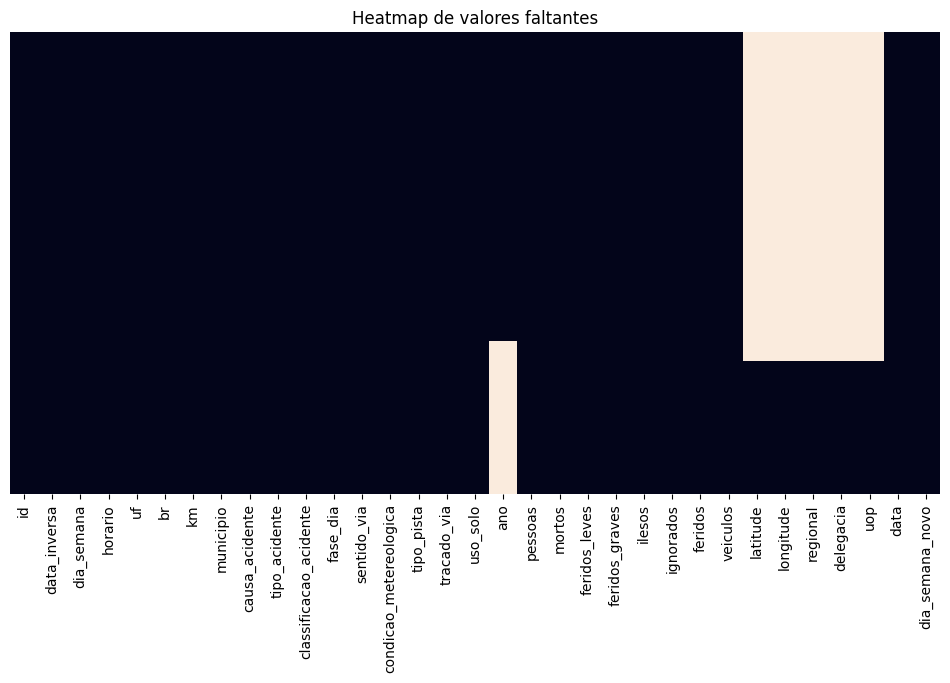

In [26]:
# Gráfico Heatmap para os valores nulos

plt.figure(figsize=(12, 6))
sns.heatmap(bases.isnull(), cbar=False, yticklabels=False)
plt.title("Heatmap de valores faltantes")
plt.show()

conclusão sobre os valores nulos:
* A coluna ano esteve presente até as extrações de 2015. Contudo a coluna de data_inversa pode servir para preencher o valores nulos das demais tabelas.
* As colunas latitude, longitude, regional, delegacia e uop não são passíveis de preenchimento considerando a precisão dos dados relacionados a localidade. Como também, os dados estão bastante vazios. Estas colunas não continuarão nos dados futuramente.

checando valores duplicados

In [27]:
bases.duplicated().sum()

np.int64(0)

Analisando estaticamente a distribuição dos dados

In [28]:
bases.describe().round(0)

,id,br,km,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data
count,2194834.0,2194822.0,2194822.0,1465837.0,2194834.0,2194834.0,2194834.0,2194834.0,2194834.0,2194834.0,2194834.0,2194834.0,6.326340e+05,6.326340e+05,2194834
mean,18367033.0,212.0,262.0,2011.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,-1.721000e+03,-6.546000e+03,2014-08-20 12:01:07.865542400
min,8.0,0.0,-870.0,2007.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.033383e+09,-4.016764e+09,2007-01-01 00:00:00
25%,401349.0,101.0,79.0,2009.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-2.500000e+01,-5.000000e+01,2010-09-08 00:00:00
50%,709678.0,158.0,201.0,2011.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,-2.000000e+01,-4.800000e+01,2013-08-05 00:00:00
75%,1258258.0,324.0,412.0,2013.0,3.0,0.0,1.0,0.0,2.0,0.0,1.0,2.0,-1.300000e+01,-4.300000e+01,2017-12-12 00:00:00
max,83529889.0,958.0,9967.0,2015.0,248.0,37.0,83.0,222.0,99.0,88.0,239.0,131.0,1.630000e+02,7.170000e+02,2025-12-31 00:00:00
std,33944326.0,129.0,229.0,2.0,2.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.299797e+06,5.050815e+06,NaN


Observações:
* A coluna de ano obtém o máximo em 2015 contudo as bases vão até 2025.
* Informações relacionadas a quantidade de pessoas e feridos obtém valores de máximo passíveis de verificação pois são número altos.
* A quantidade máxima de veículos nos chama atenção para algum tipo de validação pois está acima de 100

Em resumo: Esta base indica a presença de outliers em suas colunas.

In [29]:
# Criando a nova coluna de ano baseada na data_inversa
bases['ano_novo'] = bases['data'].dt.year

In [30]:
# retirando da base as colunas que só se apresentam após 2016
bases.drop(columns={'latitude','longitude','delegacia','uop','regional'},inplace=True)

In [31]:
bases.shape

(2194834, 29)

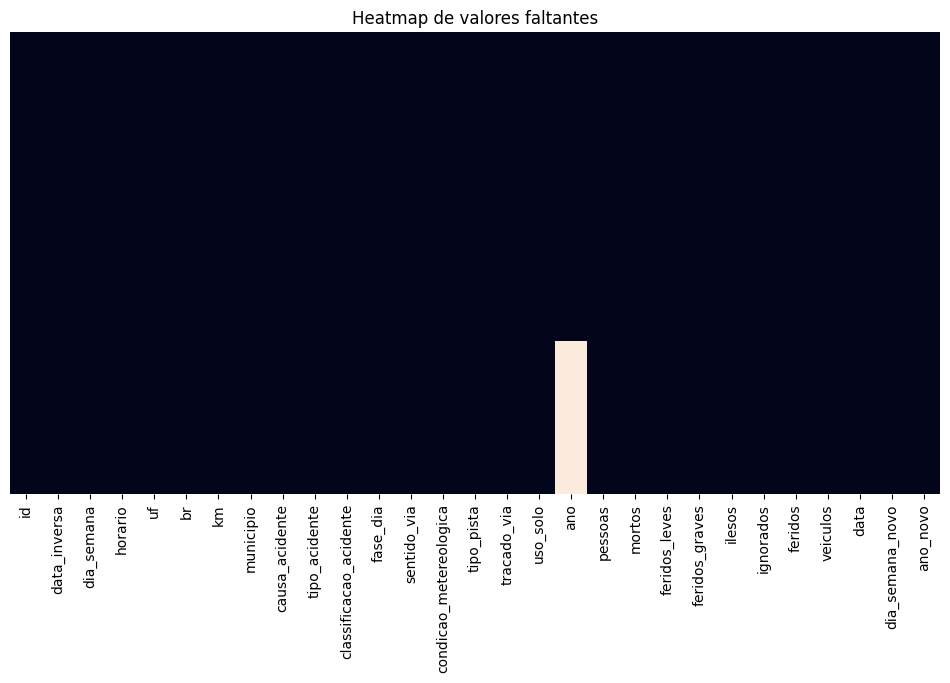

In [32]:
plt.figure(figsize=(12, 6))
sns.heatmap(bases.isnull(), cbar=False, yticklabels=False)
plt.title("Heatmap de valores faltantes")
plt.show()

### Checando a presença de outliers

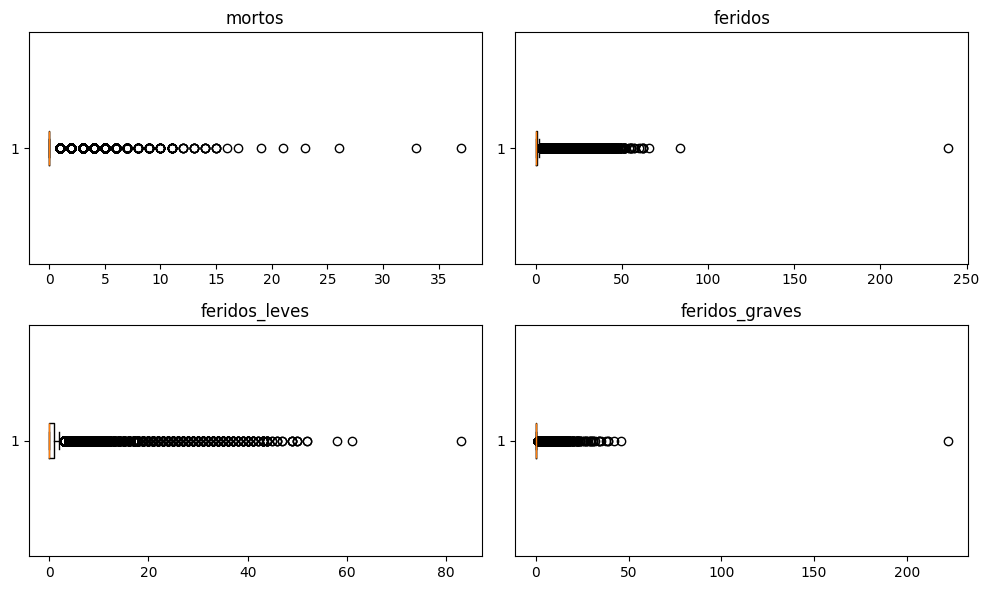

In [33]:
cols = ['mortos','feridos','feridos_leves','feridos_graves']

fig, axes = plt.subplots(2, 2, figsize=(10,6))
axes = axes.flatten() 

for ax, col in zip(axes, cols):
    ax.boxplot(bases[col].dropna(), vert=False)
    ax.set_title(col)

plt.tight_layout()
plt.show()

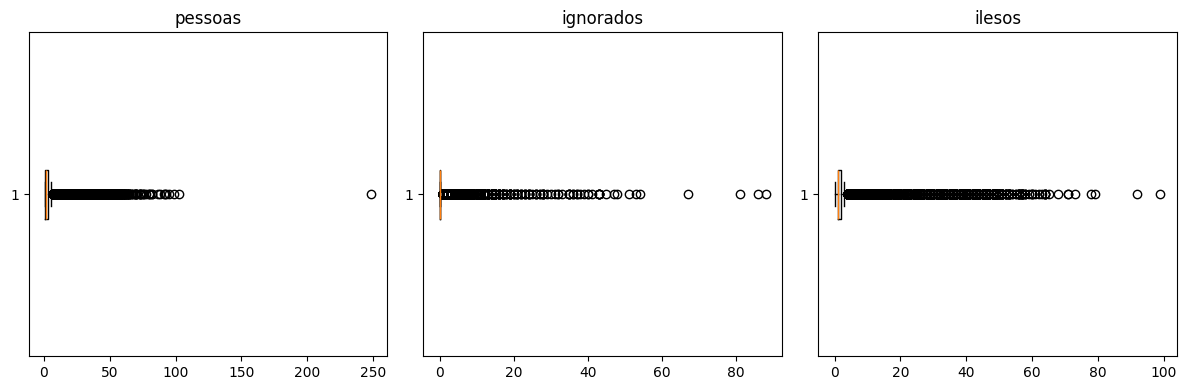

In [34]:
cols = ['pessoas','ignorados','ilesos']

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, col in zip(axes, cols):
    ax.boxplot(bases[col].dropna(), vert=False)
    ax.set_title(col)

plt.tight_layout()
plt.show()

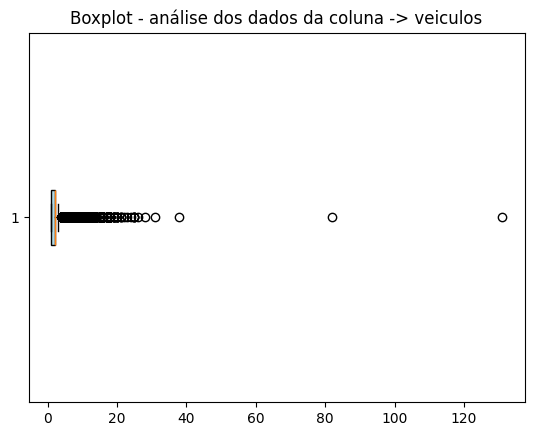

In [35]:
plt.boxplot(bases['veiculos'],patch_artist=True,vert=False, boxprops=dict(facecolor='lightblue'),label='pessoas')
plt.title("Boxplot - análise dos dados da coluna -> veiculos")
plt.show()

Visualizando estes gráficos é possível identificar que há bastante outlier nos dados e que necessitamos tratá-los.

In [36]:
bases[bases['veiculos'] >= 80].head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,data,dia_semana_novo,ano_novo
17558,595429.0,2023-09-02,sábado,14:20:00,PR,277.0,136.0,BALSA NOVA,Neblina,Colisão traseira,...,5,6,6,38,88,12,131,2023-09-02,sabado,2023
10262,707992.0,2025-07-07,segunda-feira,07:30:00,GO,80.0,62.9,PADRE BERNARDO,Demais falhas mecânicas ou elétricas,Incêndio,...,0,0,0,1,81,0,82,2025-07-07,segunda,2025


Pesquisando os casos com valores de veículos acima de 100, econtrei o acidente de BALSA NOVA :

https://g1.globo.com/pr/parana/noticia/2023/09/02/grave-acidente-br-277.ghtml

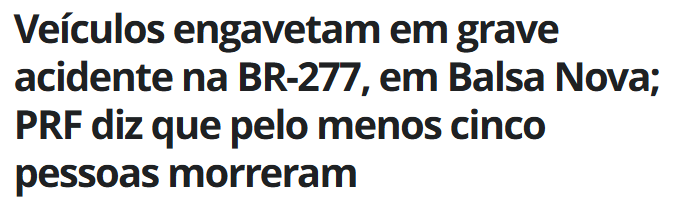

In [37]:
bases[bases['pessoas'] >= 200].head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,data,dia_semana_novo,ano_novo
69664,1110452.0,2012-05-25,Sexta,05:45:00,BA,101.0,816.0,ITAMARAJU,Outras,Colisão traseira,...,6,17,222,1,2,239,6,2012-05-25,sexta,2012


Reportagem : https://g1.globo.com/bahia/noticia/2012/05/acidente-na-br-101-ja-gerou-mais-de-200-feridos-e-6-mortos-diz-secretaria.html

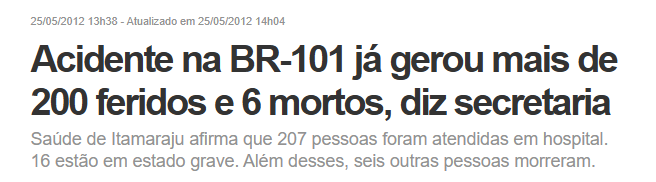

**REMOÇÃO DE OUTLIERS**

Analisando os dados que são discrepantes do modelo, é possível identificar que são casos de acidentes muito graves notificados na mídia. Logo, não são valores que podem ser considerados lixo pois refletem uma situação real. Neste caso, o indicado não seria remové-los mas aplicar uma modelagem que seja robusta e consiga lidar com a presença deles.

Vamos analisar a quantidade de valores mais extremos considerando a quantidade de pessoas envolvidas nos acidentes acima de 100

In [38]:
bases[bases['pessoas'] >= 100].count()

id                        2
data_inversa              2
dia_semana                2
horario                   2
uf                        2
br                        2
km                        2
municipio                 2
causa_acidente            2
tipo_acidente             2
classificacao_acidente    2
fase_dia                  2
sentido_via               2
condicao_metereologica    2
tipo_pista                2
tracado_via               2
uso_solo                  2
ano                       2
pessoas                   2
mortos                    2
feridos_leves             2
feridos_graves            2
ilesos                    2
ignorados                 2
feridos                   2
veiculos                  2
data                      2
dia_semana_novo           2
ano_novo                  2
dtype: int64

### Perguntas aos dados - Geração de Análises Gráficas

* Quais são as principais causas mapeadas de sinistros?
* Quais são as ufs que apresentam maior quantidade de sinistro?
* Quais são os municípios com maior quantidade de sinistros?
* Qual dia da semana apresenta mais sinistro?
* Quais brs apresentam mais sinistros com registro de pessoas mortas?
* Qual horário apresenta maior incidência de sinistros?

**Quais são as principais causas mapeadas de sinistros?**

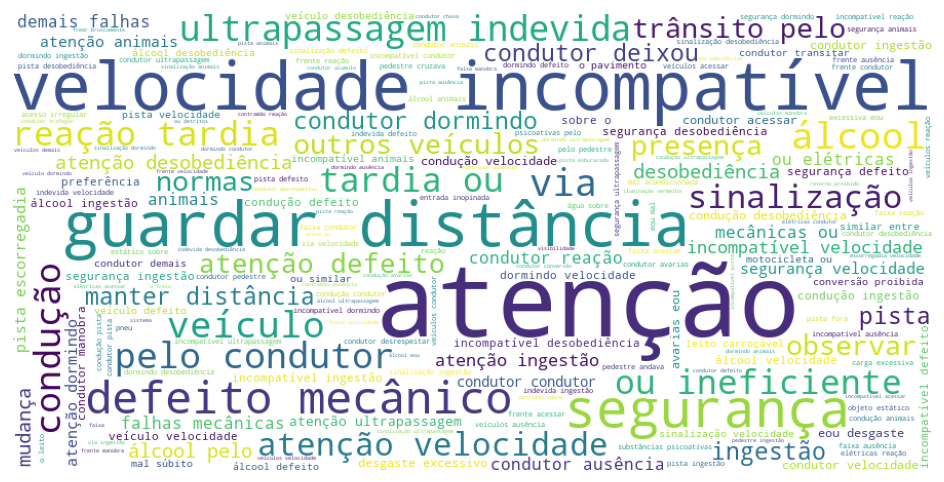

In [39]:
from wordcloud import WordCloud, STOPWORDS
import re

# juntar textos da coluna
texto = " ".join(bases['causa_acidente'].dropna().astype(str))

# limpar pontuação e números
texto = re.sub(r'[^a-zA-ZÀ-ÿ\s]', '', texto.lower())

# stopwords padrão + português personalizado
stopwords = set(STOPWORDS)
stopwords.update([
    'de','da','do','das','dos','e','em','para','com','sem','na','no',
    'nas','nos','por','que','se','ao','aos','à','às','outras','não','falta'
])

# gerar wordcloud
wc = WordCloud(
    width=900,
    height=450,
    background_color='white',
    stopwords=stopwords,
    colormap='viridis'
).generate(texto)

# plotar
plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

**REPORTAGENS RELACIONADAS A ATENÇÃO NA DIREÇÃO**

https://www.detran.pe.gov.br/noticias/2135-detran-pe-alerta-para-o-numero-crescente-do-uso-de-celular-na-direcao

**TOP 10 tipos de acidentes mais recorrentes**

In [40]:
bases.groupby(bases['tipo_acidente'])['mortos'].sum().reset_index().sort_values(by=['mortos'],ascending=False).head(10)

,tipo_acidente,mortos
12,Colisão frontal,39070
3,Atropelamento de pessoa,12655
17,Colisão traseira,11649
1,Atropelamento de Pedestre,8231
27,Saída de Pista,7985
5,Colisão Transversal,6869
13,Colisão lateral,6868
28,Saída de leito carroçável,5988
4,Capotamento,4735
16,Colisão transversal,4139


**Quais são as ufs com maior quantidade de mortos?**

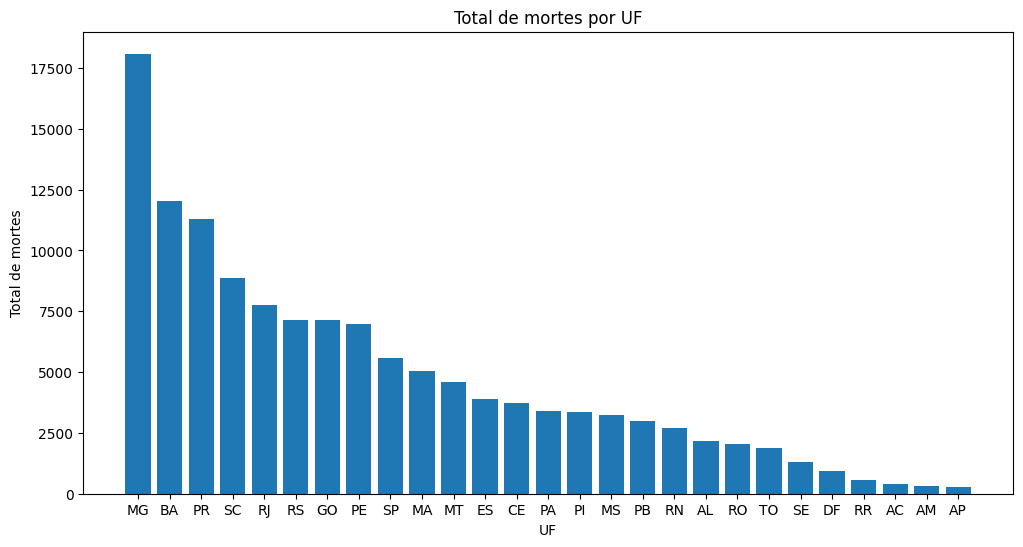

In [41]:
df_grafico = bases.groupby(['uf'])['mortos'].sum().reset_index().sort_values(by=['mortos'],ascending=False)


plt.figure(figsize=(12,6))
plt.bar(df_grafico['uf'],df_grafico['mortos'])
plt.title("Total de mortes por UF")
plt.xlabel("UF")
plt.ylabel("Total de mortes")
plt.show()

**Recorte do ano de 2025**

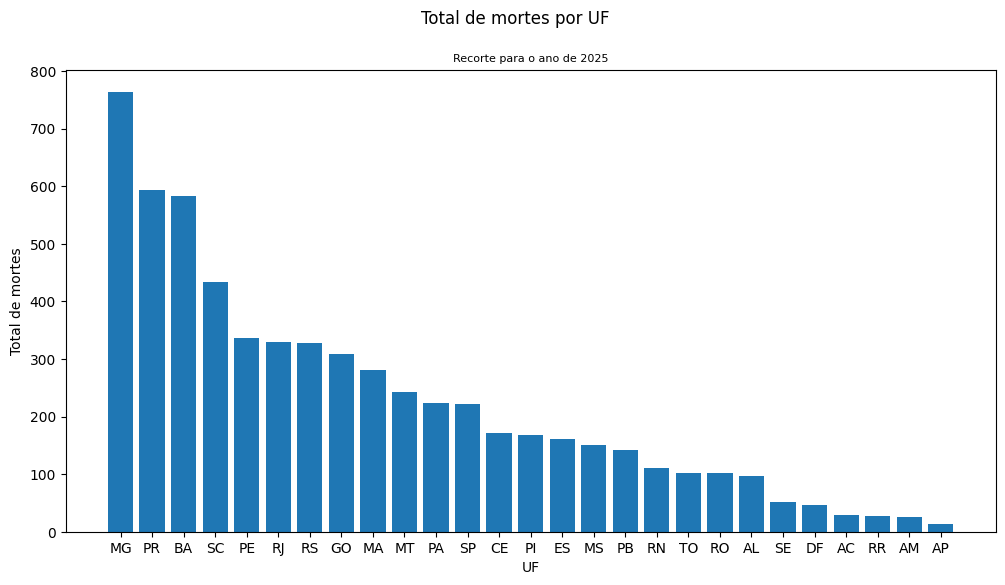

In [55]:
df_grafico = bases[bases['ano_novo'] == 2025].groupby(['uf'])['mortos'].sum().reset_index().sort_values(by=['mortos'],ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_grafico['uf'],df_grafico['mortos'])
plt.suptitle("Total de mortes por UF",fontsize=12)
plt.title("Recorte para o ano de 2025",fontsize=8)
plt.xlabel("UF")
plt.ylabel("Total de mortes")
plt.show()

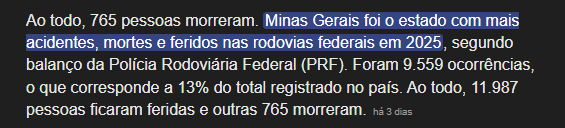

https://g1.globo.com/mg/minas-gerais/noticia/2026/02/10/mg-e-o-estado-com-mais-acidentes-mortes-e-feridos-nas-rodovias-federais-aponta-prf.ghtml

 **Qual dia da semana apresenta mais sinistro?**

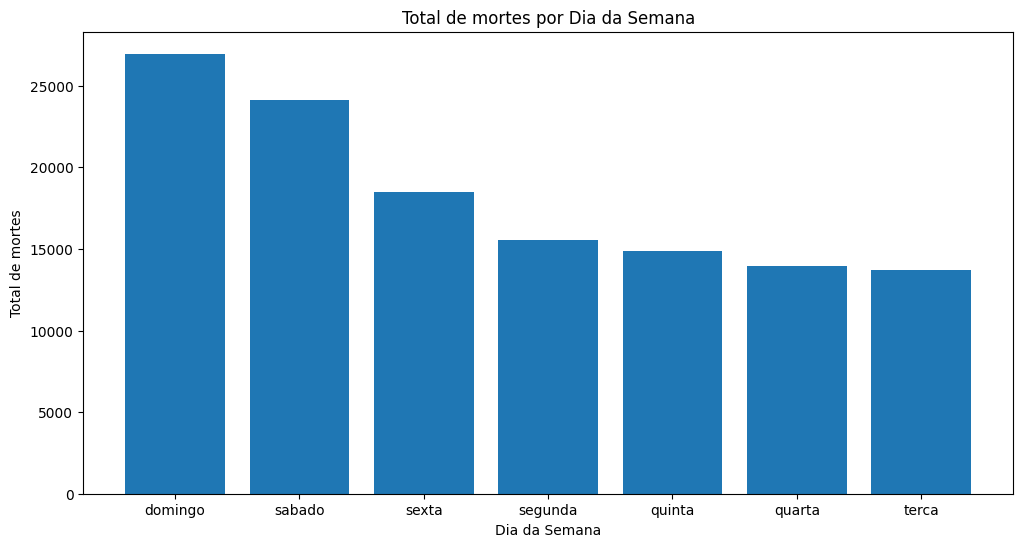

In [43]:
df_dia_semana = bases.groupby(['dia_semana_novo'])['mortos'].sum().reset_index().sort_values(by=['mortos'],ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_dia_semana['dia_semana_novo'],df_dia_semana['mortos'])
plt.title("Total de mortes por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Total de mortes")
plt.show()

**Qual horário apresenta maior incidência de sinistros?**

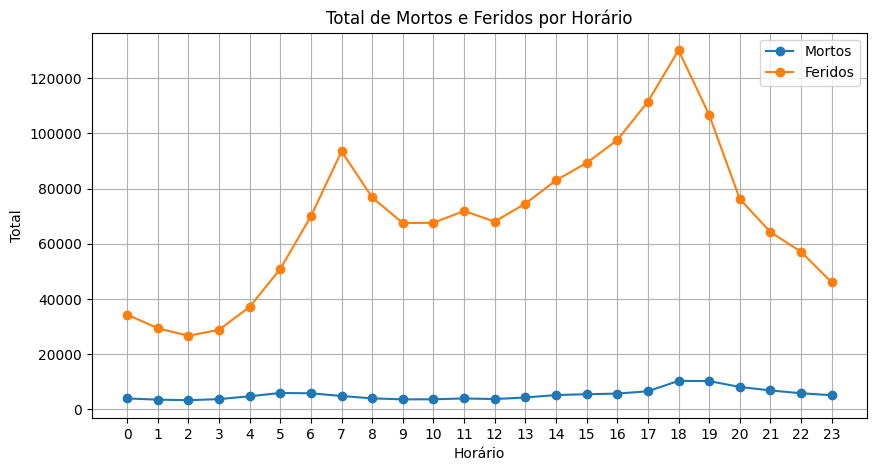

In [44]:
bases['hora'] = bases['horario'].apply(lambda t: t.hour)

df_horario = bases.groupby('hora')[['mortos','feridos']].sum()

x = df_horario.index.astype(str)

# Plot
plt.figure(figsize=(10,5))
plt.plot(x, df_horario['mortos'], marker='o', label='Mortos')
plt.plot(x, df_horario['feridos'], marker='o', label='Feridos')

# Personalização
plt.title('Total de Mortos e Feridos por Horário')
plt.xlabel('Horário')
plt.ylabel('Total')
plt.legend()
plt.grid(True)

plt.show()

Os horários de pico 07:00 e 18:00 são aqueles que apresentam maiores feridos. Uma coisa que chama atenção é a quantidade de mortes, pois pela manhã o volume é consideravelmente baixo contudo a partir das 18hrs o número aumenta. Sendo assim, é muito mais perigoso acidentes após as 18hrs da noite por terem maior propensão de vítimas fatais.

Evolução de mortos e feridos ao longo dos anos

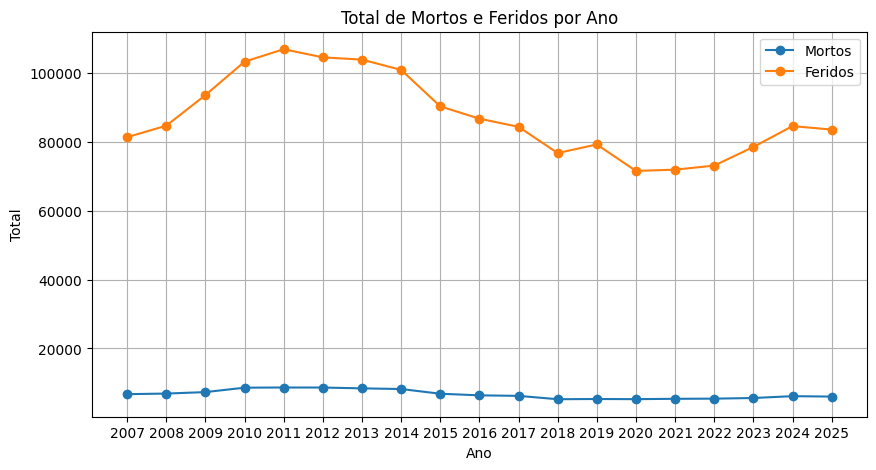

In [45]:
df_ano = bases.groupby('ano_novo')[['mortos','feridos']].sum()

x = df_ano.index.astype(str)

# Plot
plt.figure(figsize=(10,5))
plt.plot(x, df_ano['mortos'], marker='o', label='Mortos')
plt.plot(x, df_ano['feridos'], marker='o', label='Feridos')

# Personalização
plt.title('Total de Mortos e Feridos por Ano')
plt.xlabel('Ano')
plt.ylabel('Total')
plt.legend()
plt.grid(True)

plt.show()

* É possível notar que durante o período de pandemia os números de feridos diminuíram consideravelmente.
* O ano de 2025 teve uma diminuição leve em comparação com o ano de 2024.
* Algo que chama atenção é que durante 2008 e 2016 tivemos um pico sobre o número de feridos. E a lei seca no Brasil começou a vigorar a partir de 2008.

Vamos analisar considerando os casos de incidente por álcool para identificar como ele evoluiu ao longo dos anos após a lei seca.

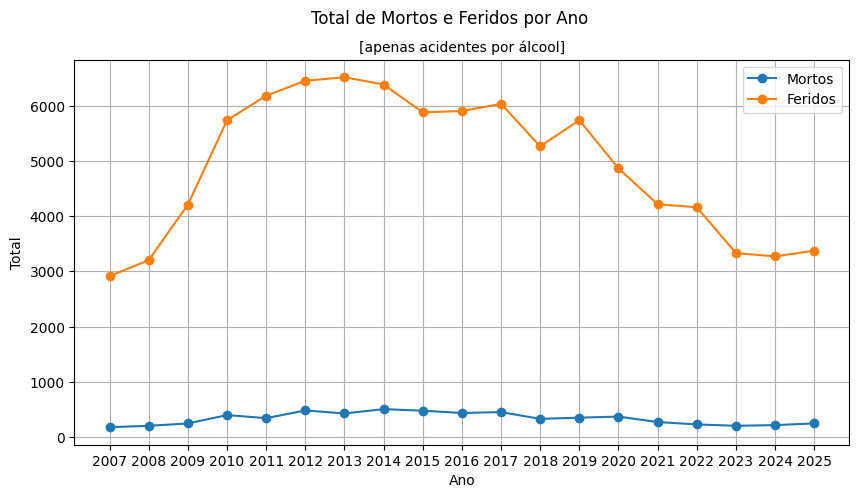

In [56]:
df_hist_alcool = bases[bases['causa_acidente'].str.lower().str.contains("álcool",na=False)].copy()


df_ano = df_hist_alcool.groupby('ano_novo')[['mortos','feridos']].sum()

x = df_ano.index.astype(str)

# Plot
plt.figure(figsize=(10,5))
plt.plot(x, df_ano['mortos'], marker='o', label='Mortos')
plt.plot(x, df_ano['feridos'], marker='o', label='Feridos')

# Personalização
plt.suptitle('Total de Mortos e Feridos por Ano',fontsize=12)
plt.title("[apenas acidentes por álcool]", fontsize=10)
plt.xlabel('Ano')
plt.ylabel('Total')
plt.legend()
plt.grid(True)

plt.show()

Quais são os 10 municípios com maior quantidade de mortos?

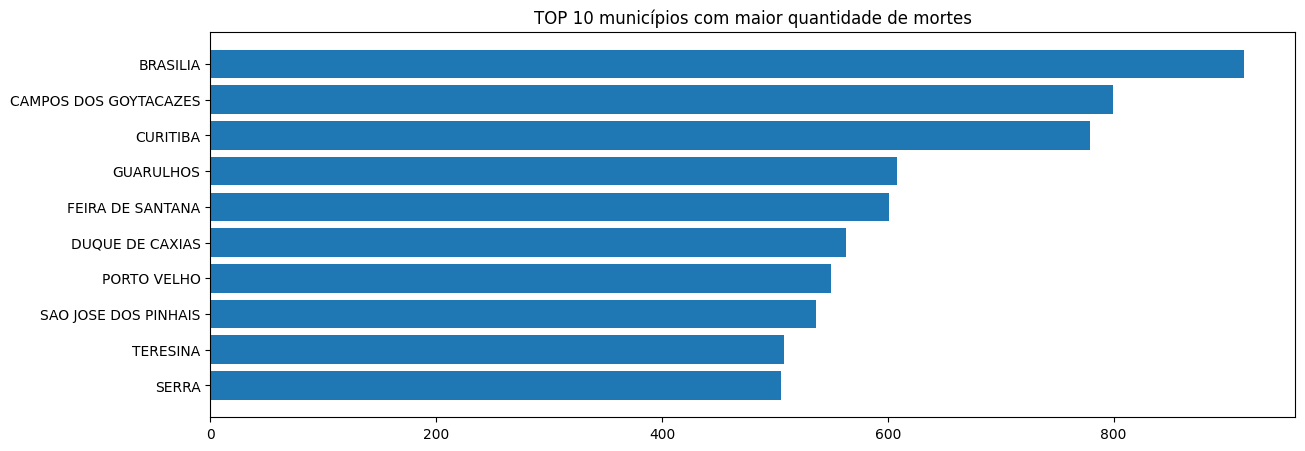

In [47]:
df_mun = bases.groupby(['municipio'])['mortos'].sum().reset_index().sort_values(by='mortos',ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.barh(df_mun['municipio'],df_mun['mortos'])
plt.title('TOP 10 municípios com maior quantidade de mortes')

plt.gca().invert_yaxis()
plt.show()

Recorte do ano de 2025

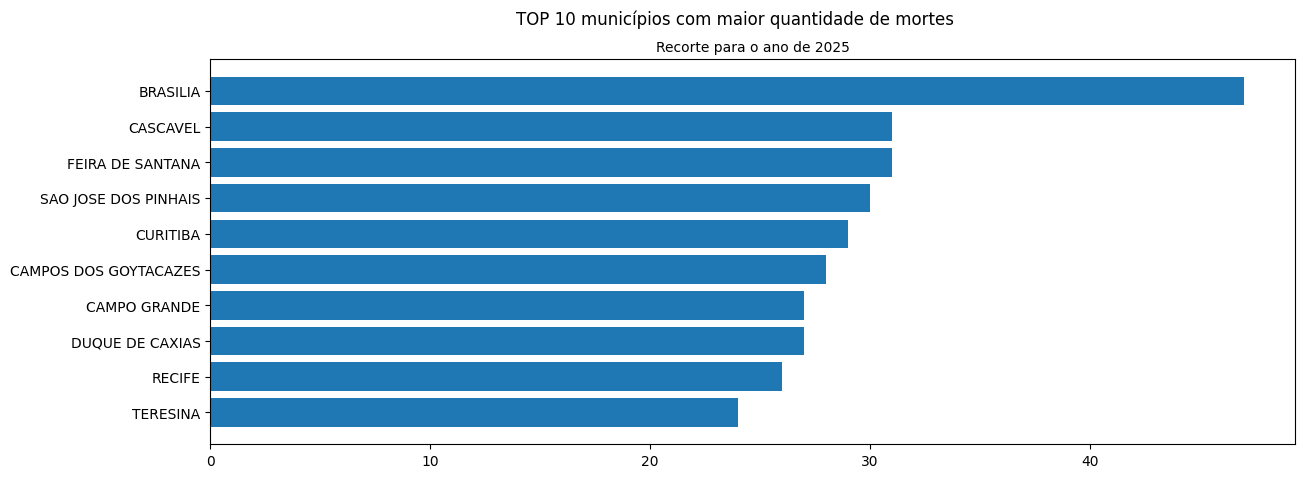

In [58]:
df_mun_2025 = bases[bases['ano_novo'] == 2025].groupby(['municipio'])['mortos'].sum().reset_index().sort_values(by='mortos',ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.barh(df_mun_2025['municipio'],df_mun_2025['mortos'])
plt.suptitle('TOP 10 municípios com maior quantidade de mortes',fontsize=12)
plt.title("Recorte para o ano de 2025",fontsize=10)
plt.gca().invert_yaxis()
plt.show()


Quais são as TOP 15 brs com maior quantidade de mortos?

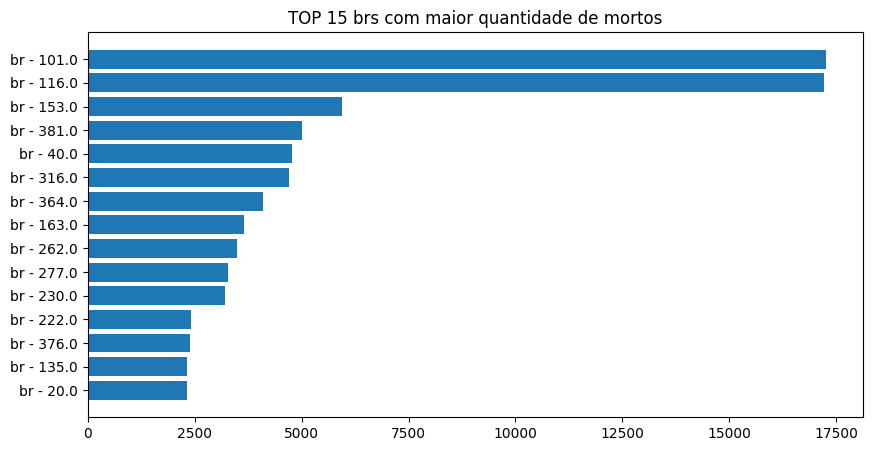

In [49]:
df_brs = bases.copy()

df_brs['km_br'] = [f"br - {str(i)}" for i in bases['br']] 

df_brs_graf = df_brs.groupby(['km_br'])['mortos'].sum().reset_index().sort_values(by='mortos',ascending=False).head(15)

plt.figure(figsize=(10,5))
plt.barh(df_brs_graf['km_br'],df_brs_graf['mortos'])
plt.title('TOP 15 brs com maior quantidade de mortos')
plt.gca().invert_yaxis()
plt.show()

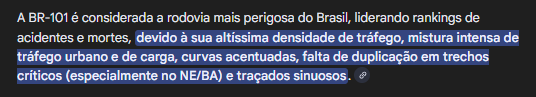

https://brasil61.com/n/br-101-continua-sendo-a-rodovia-mais-perigosa-do-brasil-bras2412811#:~:text=especialista%20em%20mobilidade-,%E2%80%9CTodas%20as%20estradas%20que%20inicialmente%20foram%20feitas%20ligando%20as%20capitais,tamb%C3%A9m%20a%20quantidade%20de%20acidentes.%E2%80%9D&text=Pol%C3%ADcia%20Rodovi%C3%A1ria%20Federal-,%E2%80%9CTodo%20o%20sistema%20vi%C3%A1rio%20%C3%A9%20constru%C3%ADdo%20pensando%20em%20dar%20seguran%C3%A7a,colis%C3%A3o%20frontal%2C%20altamente%20mortal.%E2%80%9D

Quais são os meses que apresentam maior quantidade de feridos?

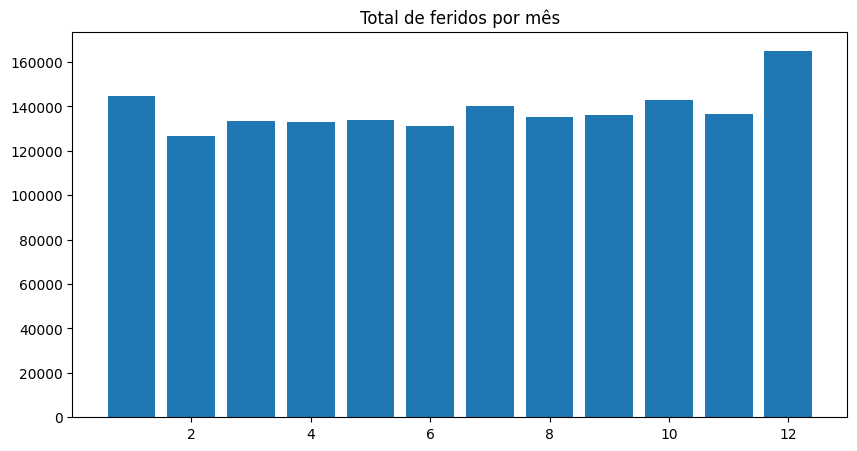

In [50]:
df_meses = bases.copy()

df_meses['meses'] = bases['data'].dt.month

df_meses_graf = df_meses.groupby(['meses'])['feridos'].sum().reset_index().sort_values(by='feridos',ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_meses_graf['meses'],df_meses_graf['feridos'])
plt.title('Total de feridos por mês')
plt.show()

Reportagem: https://g1.globo.com/jornal-nacional/noticia/2025/12/25/brasil-registra-quase-2-mil-acidentes-em-rodovias-federais-nos-dias-que-antecederam-natal.ghtml

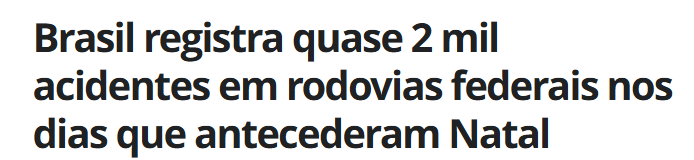

Condições meteorológicas

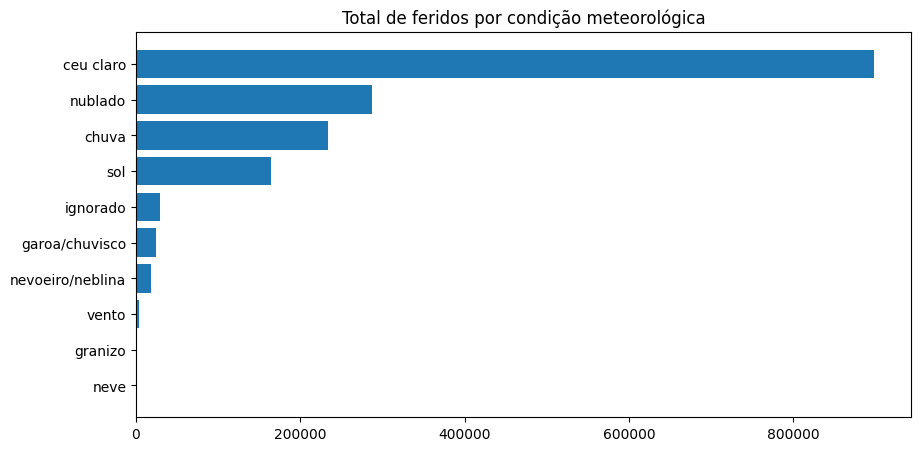

In [51]:
df_cond_met = bases.groupby(['condicao_metereologica'])['feridos'].sum().reset_index().sort_values(by='feridos',ascending=False)

plt.figure(figsize=(10,5))
plt.barh(df_cond_met['condicao_metereologica'],df_cond_met['feridos'])
plt.title("Total de feridos por condição meteorológica")
plt.gca().invert_yaxis()
plt.show()

Fase do dia

In [52]:
bases.groupby(['fase_dia'])['feridos'].sum().reset_index().sort_values(by='feridos',ascending=False)

,fase_dia,feridos
3,pleno dia,905773
2,plena noite,565815
1,anoitecer,97654
0,amanhecer,89424


### Análises estatísticas

* Qual é a porcentagem de pessoas feridas considerando o total de pessoas envolvidas nos acidentes?
    * abertura por período de meses, horários e anos
* Qual é a porcentagem de pessoas mortas considerando o total de pessoas envolvidas nos acidentes?
    * abertura por período de meses, horários e anos
* Qual é a porcentagem de pessoas ilesas considerando o total de pessoas envolvidas nos acidentes?
    * abertura por período de meses, horários e anos
* Quantos porcentos tivemos de diminuição ou aumento considerando a evolução de feridos ao longo dos anos?
* Qual o percentual de acidentes envolvendo alcoolismo?


### Resumo

**Principais modificações no dataset**

1. Criação de colunas a partir da data_inversa: data, meses, ano
2. Ajuste nas padronizações dos valores categóricos para numéricos: latitude, longitude, br, km
3. Remoção de colunas que não estão presentes no histórico: regional, delegacia, uop, latitude e longitude
4. Padronização dos valores categóricos: fase_dia, condicao_metereologica

**Principais análises**
1. Aplicação da Lei seca a partir de 2008
2. Principais ufs, brs e municípios com maior quantidade de número de mortos
3. Quantidade de feridos num período de meses, anos e horário
4. Quais as principais causas de acidentes através da nuvem de palavras
5. Quais são os tipos de acidentes que contém maior quantidade de mortos
6. Quais são os dias da semana com maior quantidade de mortes
7. Análise da permanência dos outliers